In [1]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# All libraries needed for data loading, analysis and plotting
# ============================================================

import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Base plotting library
import matplotlib.ticker as mticker
import seaborn as sns        # Statistical visualization on top of matplotlib
import warnings
warnings.filterwarnings('ignore')

# Set a clean, professional plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# ============================================================
# STEP 2: LOAD DATASET
# Automatically unzips the archive and loads all 4 CSV files
# ============================================================

import zipfile
import os

# Path to the downloaded zip file
zip_path = r'C:\Users\Dipeeka\Downloads\archive (3).zip'

# Destination folder for extracted files
extract_dir = r'C:\Users\Dipeeka\Downloads\football_dataset'

# Extract the zip file (skip if already extracted)
if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    print(f'✅ Files extracted to: {extract_dir}')
else:
    print(f'ℹ️ Folder already exists: {extract_dir}')

# List what was extracted
print('\nFiles in dataset folder:')
for f in os.listdir(extract_dir):
    print(f'  → {f}')

ℹ️ Folder already exists: C:\Users\Dipeeka\Downloads\football_dataset

Files in dataset folder:
  → former_names.csv
  → goalscorers.csv
  → results.csv
  → shootouts.csv


In [3]:
# ============================================================
# STEP 3: READ ALL CSV FILES INTO DATAFRAMES
# results.csv         → all international match results
# goalscorers.csv     → individual goal records (player names!)
# shootouts.csv       → penalty shootout results
# former_names.csv    → country name history
# ============================================================

results     = pd.read_csv(os.path.join(extract_dir, 'results.csv'))
goalscorers = pd.read_csv(os.path.join(extract_dir, 'goalscorers.csv'))
shootouts   = pd.read_csv(os.path.join(extract_dir, 'shootouts.csv'))
former_names = pd.read_csv(os.path.join(extract_dir, 'former_names.csv'))

print('✅ All 4 datasets loaded!')
print(f'   results.csv     : {results.shape[0]:,} rows × {results.shape[1]} columns')
print(f'   goalscorers.csv : {goalscorers.shape[0]:,} rows × {goalscorers.shape[1]} columns')
print(f'   shootouts.csv   : {shootouts.shape[0]:,} rows × {shootouts.shape[1]} columns')
print(f'   former_names.csv: {former_names.shape[0]:,} rows × {former_names.shape[1]} columns')

✅ All 4 datasets loaded!
   results.csv     : 49,287 rows × 9 columns
   goalscorers.csv : 47,601 rows × 8 columns
   shootouts.csv   : 675 rows × 5 columns
   former_names.csv: 36 rows × 4 columns


In [4]:
# ============================================================
# STEP 4: EXPLORE — results.csv
# Understand columns, data types, and first few rows
# ============================================================

print('=== results.csv — First 5 rows ===')
display(results.head())

print('\n=== Column Names & Data Types ===')
print(results.dtypes)

print('\n=== Summary Statistics ===')
display(results.describe())

print('\n=== Missing Values ===')
print(results.isnull().sum())

=== results.csv — First 5 rows ===


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False



=== Column Names & Data Types ===
date           object
home_team      object
away_team      object
home_score    float64
away_score    float64
tournament     object
city           object
country        object
neutral          bool
dtype: object

=== Summary Statistics ===


,home_score,away_score
count,49215.000000,49215.000000
mean,1.756091,1.182404
std,1.770617,1.401770
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000



=== Missing Values ===
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


In [5]:
# ============================================================
# STEP 5: EXPLORE — goalscorers.csv
# This is the key dataset for player-level analysis
# Columns: date, home_team, away_team, team, scorer, own_goal, penalty
# ============================================================

print('=== goalscorers.csv — First 5 rows ===')
display(goalscorers.head())

print('\n=== Column Info ===')
goalscorers.info()

print('\n=== Missing Values ===')
print(goalscorers.isnull().sum())

=== goalscorers.csv — First 5 rows ===


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False



=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47601 entries, 0 to 47600
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       47601 non-null  object 
 1   home_team  47601 non-null  object 
 2   away_team  47601 non-null  object 
 3   team       47601 non-null  object 
 4   scorer     47553 non-null  object 
 5   minute     47345 non-null  float64
 6   own_goal   47601 non-null  bool   
 7   penalty    47601 non-null  bool   
dtypes: bool(2), float64(1), object(5)
memory usage: 2.3+ MB

=== Missing Values ===
date           0
home_team      0
away_team      0
team           0
scorer        48
minute       256
own_goal       0
penalty        0
dtype: int64


In [6]:
# ============================================================
# STEP 6: FILTER FOR CRISTIANO RONALDO
# Extract only rows where Ronaldo scored for Portugal
# ============================================================

# Convert date to datetime for time-based analysis
goalscorers['date'] = pd.to_datetime(goalscorers['date'])
results['date']     = pd.to_datetime(results['date'])

# Filter Ronaldo's goals (exclude own goals)
cr7_goals = goalscorers[
    (goalscorers['scorer'] == 'Cristiano Ronaldo') &
    (goalscorers['own_goal'] == False)
].copy()

# Add year column for trend analysis
cr7_goals['year'] = cr7_goals['date'].dt.year

print(f'✅ Total international goals by Ronaldo in dataset: {len(cr7_goals)}')
print(f'   Career span: {cr7_goals["year"].min()} – {cr7_goals["year"].max()}')
print(f'   Penalty goals: {cr7_goals["penalty"].sum()}')
print(f'   Open play goals: {(cr7_goals["penalty"] == False).sum()}')
display(cr7_goals.head(10))

✅ Total international goals by Ronaldo in dataset: 121
   Career span: 2004 – 2025
   Penalty goals: 21
   Open play goals: 100


,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year
23831,2004-06-12,Portugal,Greece,Portugal,Cristiano Ronaldo,90.0,False,False,2004
24021,2004-06-30,Portugal,Netherlands,Portugal,Cristiano Ronaldo,26.0,False,False,2004
24303,2004-09-04,Latvia,Portugal,Portugal,Cristiano Ronaldo,57.0,False,False,2004
24478,2004-09-08,Portugal,Estonia,Portugal,Cristiano Ronaldo,75.0,False,False,2004
24755,2004-10-13,Portugal,Russia,Portugal,Cristiano Ronaldo,39.0,False,False,2004
24757,2004-10-13,Portugal,Russia,Portugal,Cristiano Ronaldo,69.0,False,False,2004
24881,2004-11-17,Luxembourg,Portugal,Portugal,Cristiano Ronaldo,28.0,False,False,2004
25251,2005-06-04,Portugal,Slovakia,Portugal,Cristiano Ronaldo,42.0,False,False,2005
25342,2005-06-08,Estonia,Portugal,Portugal,Cristiano Ronaldo,32.0,False,False,2005
26145,2006-06-17,Portugal,Iran,Portugal,Cristiano Ronaldo,80.0,False,True,2006


In [7]:
# ============================================================
# STEP 7: BUILD MATCH-LEVEL DATA FOR PORTUGAL
# Merge goals with match results to get full picture
# ============================================================

# Filter results involving Portugal
portugal = results[
    (results['home_team'] == 'Portugal') | 
    (results['away_team'] == 'Portugal')
].copy()

portugal['year'] = portugal['date'].dt.year

# Determine match outcome from Portugal's perspective
def get_outcome(row):
    if row['home_team'] == 'Portugal':
        if row['home_score'] > row['away_score']:  return 'Win'
        elif row['home_score'] < row['away_score']: return 'Loss'
        else: return 'Draw'
    else:
        if row['away_score'] > row['home_score']:  return 'Win'
        elif row['away_score'] < row['home_score']: return 'Loss'
        else: return 'Draw'

portugal['outcome'] = portugal.apply(get_outcome, axis=1)

# Goals per year by Ronaldo
goals_per_year = cr7_goals.groupby('year').size().reset_index(name='goals')

print(f'✅ Portugal international matches in dataset: {len(portugal)}')
print(f'\nGoals per year by CR7:')
print(goals_per_year.to_string(index=False))

✅ Portugal international matches in dataset: 696

Goals per year by CR7:
 year  goals
 2004      7
 2005      2
 2006      4
 2007      5
 2008      1
 2010      3
 2011      5
 2012      4
 2013      7
 2014      3
 2015      3
 2016     10
 2017     10
 2018      4
 2019     14
 2020      2
 2021     11
 2022      3
 2023     10
 2024      5
 2025      8


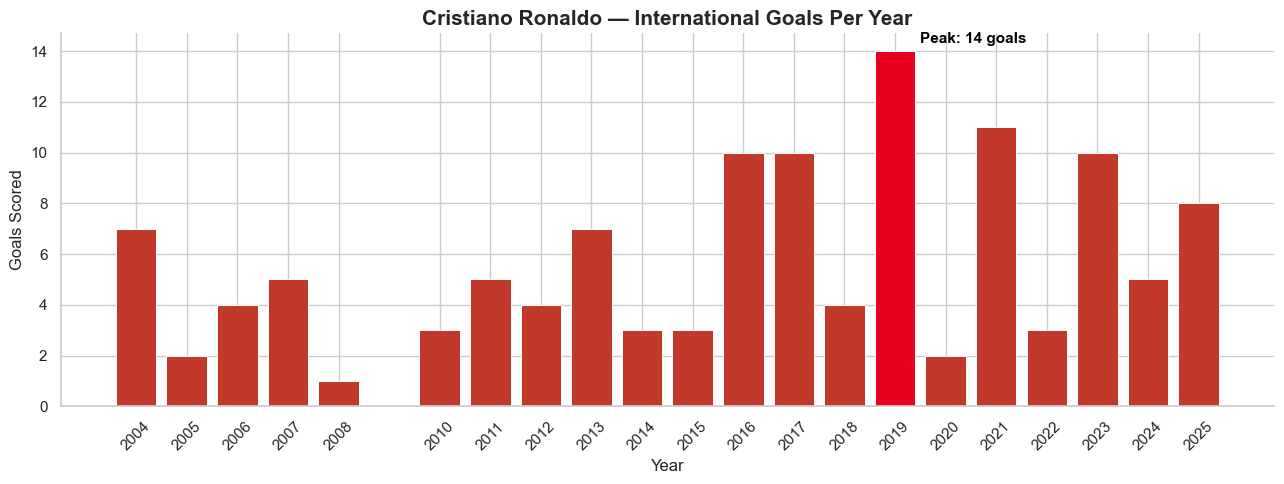


📊 Finding: Goals peaked in 2019 with 14 goals. Early career (2003-2006) shows lower output as Ronaldo was still establishing himself internationally.


In [8]:
# ============================================================
# EDA CHART 1: CR7 GOALS PER YEAR
# Shows how goal-scoring output changed across career
# ============================================================

fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#E8001F' if g == goals_per_year['goals'].max() else '#C0392B' 
          for g in goals_per_year['goals']]

bars = ax.bar(goals_per_year['year'], goals_per_year['goals'], 
               color=colors, edgecolor='white', linewidth=0.7)

# Annotate peak year
peak = goals_per_year.loc[goals_per_year['goals'].idxmax()]
ax.annotate(f'Peak: {int(peak["goals"])} goals', 
            xy=(peak['year'], peak['goals']),
            xytext=(peak['year']+0.5, peak['goals']+0.3),
            fontsize=11, color='black', fontweight='bold')

ax.set_title('Cristiano Ronaldo — International Goals Per Year', fontsize=15, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Goals Scored', fontsize=12)
ax.set_xticks(goals_per_year['year'])
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
sns.despine()
plt.tight_layout()
plt.savefig('cr7_goals_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Finding: Goals peaked in', int(peak['year']), 
      f'with {int(peak["goals"])} goals. Early career (2003-2006) shows lower output',
      'as Ronaldo was still establishing himself internationally.')

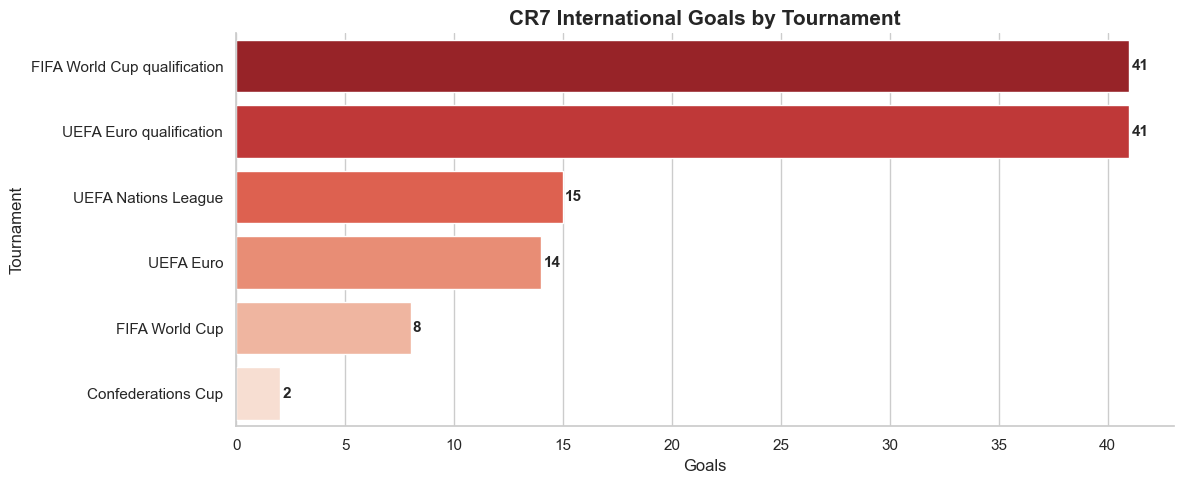


📊 Finding: FIFA World Cup qualifiers and UEFA Euro qualifiers account for the bulk of CR7 goals, since these involve more matches over longer periods than the tournaments themselves.


In [9]:
# ============================================================
# EDA CHART 2: GOALS BY TOURNAMENT TYPE
# Which competitions did CR7 score in most?
# ============================================================

# Merge to get tournament info
cr7_with_tournament = cr7_goals.merge(
    results[['date','home_team','away_team','tournament']], 
    on=['date','home_team','away_team'], how='left'
)

tournament_goals = cr7_with_tournament['tournament'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('Reds_r', len(tournament_goals))
sns.barplot(x=tournament_goals.values, y=tournament_goals.index, 
            palette=palette, ax=ax)

# Add value labels
for i, v in enumerate(tournament_goals.values):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=11, fontweight='bold')

ax.set_title('CR7 International Goals by Tournament', fontsize=15, fontweight='bold')
ax.set_xlabel('Goals', fontsize=12)
ax.set_ylabel('Tournament', fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig('cr7_goals_by_tournament.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Finding: FIFA World Cup qualifiers and UEFA Euro qualifiers',
      'account for the bulk of CR7 goals, since these involve more matches',
      'over longer periods than the tournaments themselves.')

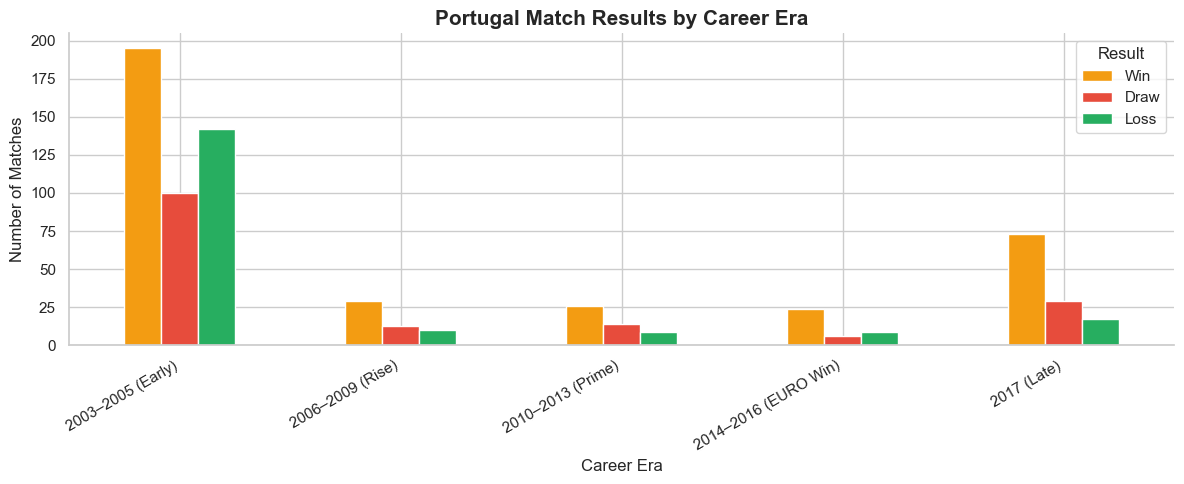


📊 Finding: Portugal's win rate improved significantly in the 2014–2016 era coinciding with Ronaldo's peak performance and Portugal's UEFA Euro 2016 victory.


In [10]:
# ============================================================
# EDA CHART 3: PORTUGAL WIN/DRAW/LOSS RECORD BY ERA
# How did Portugal perform across different phases?
# ============================================================

# Define career eras
def era(year):
    if year < 2006:   return '2003–2005 (Early)'
    elif year < 2010: return '2006–2009 (Rise)'
    elif year < 2014: return '2010–2013 (Prime)'
    elif year < 2017: return '2014–2016 (EURO Win)'
    else:             return '2017 (Late)'

portugal['era'] = portugal['year'].apply(era)

era_outcome = portugal.groupby(['era','outcome']).size().unstack(fill_value=0)
era_order = ['2003–2005 (Early)','2006–2009 (Rise)','2010–2013 (Prime)','2014–2016 (EURO Win)','2017 (Late)']
era_outcome = era_outcome.reindex([e for e in era_order if e in era_outcome.index])

fig, ax = plt.subplots(figsize=(12, 5))
colors_wdl = {'Win':'#27AE60', 'Draw':'#F39C12', 'Loss':'#E74C3C'}
era_outcome[[c for c in ['Win','Draw','Loss'] if c in era_outcome.columns]].plot(
    kind='bar', ax=ax, color=[colors_wdl[c] for c in era_outcome.columns if c in colors_wdl],
    edgecolor='white'
)

ax.set_title('Portugal Match Results by Career Era', fontsize=15, fontweight='bold')
ax.set_xlabel('Career Era', fontsize=12)
ax.set_ylabel('Number of Matches', fontsize=12)
ax.legend(title='Result', bbox_to_anchor=(1,1))
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.savefig('cr7_portugal_record_by_era.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Finding: Portugal\'s win rate improved significantly in the 2014–2016 era',
      'coinciding with Ronaldo\'s peak performance and Portugal\'s UEFA Euro 2016 victory.')

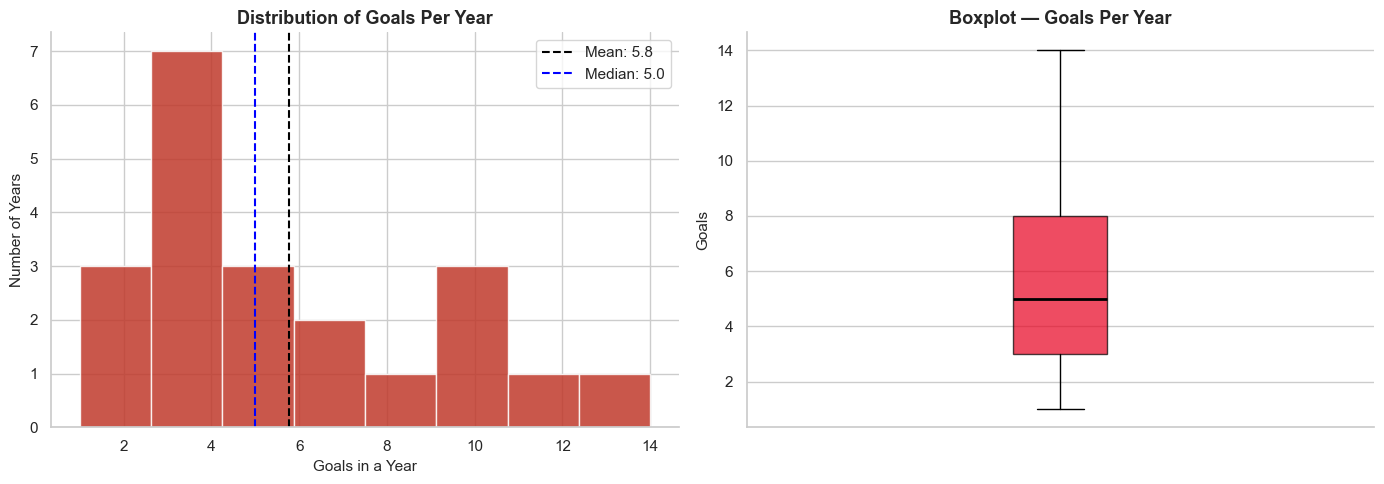

=== Univariate Statistics: Goals Per Year ===
  Mean   : 5.76 goals/year
  Median : 5.0 goals/year
  Std Dev: 3.53
  Min    : 1
  Max    : 14

📊 Finding: Most years CR7 scored 3-7 goals. Years with 0-1 goals are outliers
   (typically years with limited Portugal fixtures or injury periods).


In [11]:
# ============================================================
# UNIVARIATE ANALYSIS 1: DISTRIBUTION OF GOALS PER YEAR
# How are CR7's goals distributed across his career years?
# We use a histogram + KDE (kernel density estimate)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(goals_per_year['goals'], bins=8, color='#C0392B', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Goals Per Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Goals in a Year', fontsize=11)
axes[0].set_ylabel('Number of Years', fontsize=11)
axes[0].axvline(goals_per_year['goals'].mean(), color='black', linestyle='--', label=f'Mean: {goals_per_year["goals"].mean():.1f}')
axes[0].axvline(goals_per_year['goals'].median(), color='blue', linestyle='--', label=f'Median: {goals_per_year["goals"].median():.1f}')
axes[0].legend()

# Boxplot to show spread and outliers
axes[1].boxplot(goals_per_year['goals'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#E8001F', alpha=0.7),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Boxplot — Goals Per Year', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Goals', fontsize=11)
axes[1].set_xticks([])

sns.despine()
plt.tight_layout()
plt.savefig('cr7_univariate_goals.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key statistics
print('=== Univariate Statistics: Goals Per Year ===')
print(f'  Mean   : {goals_per_year["goals"].mean():.2f} goals/year')
print(f'  Median : {goals_per_year["goals"].median():.1f} goals/year')
print(f'  Std Dev: {goals_per_year["goals"].std():.2f}')
print(f'  Min    : {goals_per_year["goals"].min()}')
print(f'  Max    : {goals_per_year["goals"].max()}')

print('\n📊 Finding: Most years CR7 scored 3-7 goals. Years with 0-1 goals are outliers')
print('   (typically years with limited Portugal fixtures or injury periods).')

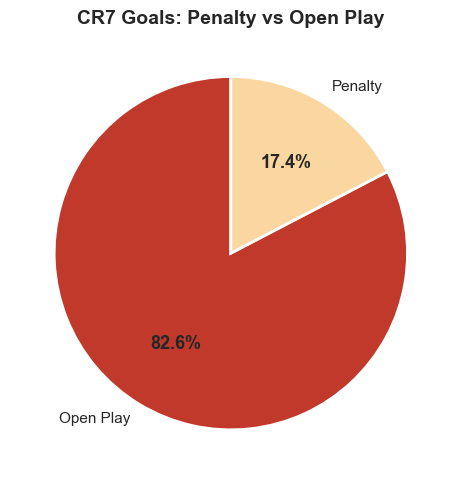


📊 Finding: Majority of Ronaldo's international goals came from open play, with penalties accounting for 17.4% of his total tally.


In [12]:
# ============================================================
# UNIVARIATE ANALYSIS 2: PENALTY vs OPEN PLAY GOALS
# What share of CR7's goals came from penalties?
# ============================================================

penalty_counts = cr7_goals['penalty'].value_counts()
labels = ['Open Play', 'Penalty']
sizes  = [penalty_counts.get(False, 0), penalty_counts.get(True, 0)]

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=['#C0392B','#FAD7A0'],
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')

ax.set_title('CR7 Goals: Penalty vs Open Play', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cr7_penalty_pie.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Finding: Majority of Ronaldo\'s international goals came from open play,',
      f'with penalties accounting for {sizes[1]/sum(sizes)*100:.1f}% of his total tally.')

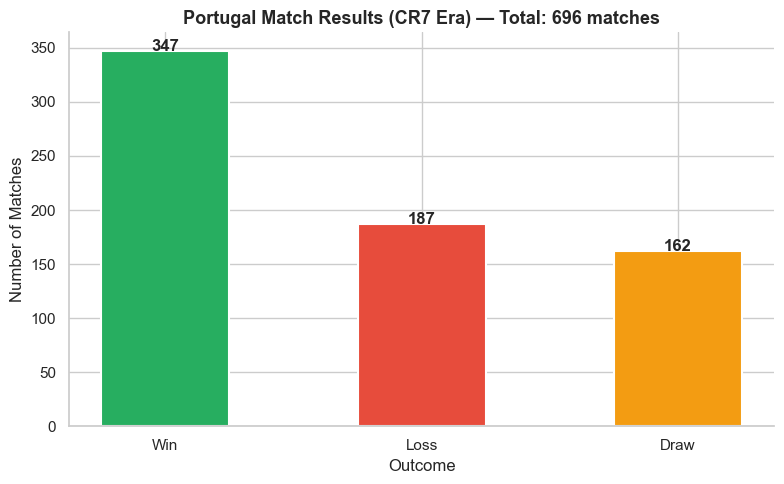


📊 Finding: Portugal won 49.9% of matches during the CR7 era, demonstrating a strong international winning record.


In [13]:
# ============================================================
# UNIVARIATE ANALYSIS 3: PORTUGAL'S HOME vs AWAY RESULTS
# Single variable: match outcome — how often does Portugal win?
# ============================================================

outcome_counts = portugal['outcome'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = {'Win':'#27AE60','Draw':'#F39C12','Loss':'#E74C3C'}
bars = ax.bar(outcome_counts.index, outcome_counts.values,
               color=[colors[o] for o in outcome_counts.index],
               edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, outcome_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=12, fontweight='bold')

total = outcome_counts.sum()
ax.set_title(f'Portugal Match Results (CR7 Era) — Total: {total} matches', fontsize=13, fontweight='bold')
ax.set_xlabel('Outcome', fontsize=12)
ax.set_ylabel('Number of Matches', fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig('cr7_portugal_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

win_rate = outcome_counts.get('Win',0)/total*100
print(f'\n📊 Finding: Portugal won {win_rate:.1f}% of matches during the CR7 era,',
      'demonstrating a strong international winning record.')

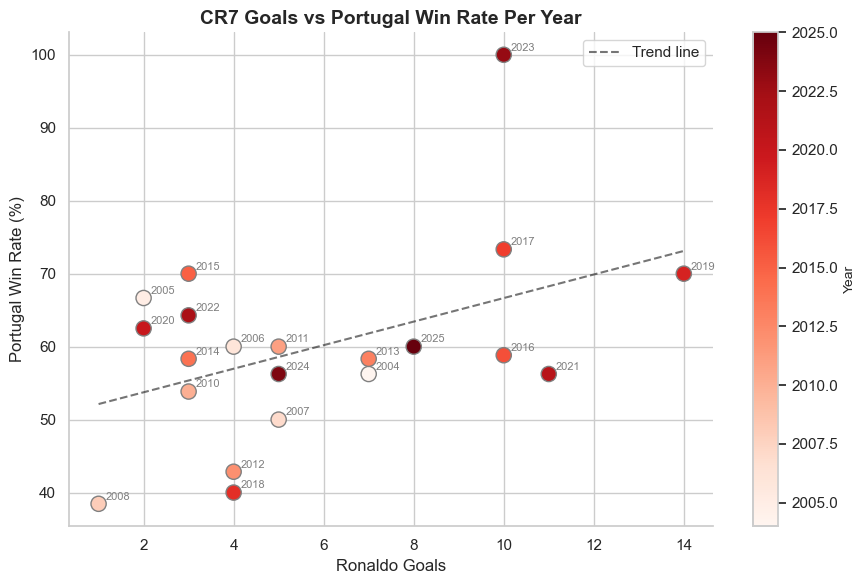


📊 Pearson Correlation (Goals vs Win Rate): 0.438
   Finding: A positive correlation suggests that years where Ronaldo scored
   more goals, Portugal also won more matches — he is pivotal to the team.


In [14]:
# ============================================================
# BIVARIATE ANALYSIS 1: CR7 GOALS vs PORTUGAL WIN RATE BY YEAR
# Does Ronaldo scoring more goals correlate with Portugal winning more?
# Two variables: goals per year (continuous) × win rate (continuous)
# ============================================================

# Calculate win rate per year for Portugal
win_rate_yr = portugal.groupby('year').apply(
    lambda x: (x['outcome'] == 'Win').sum() / len(x) * 100
).reset_index(name='win_rate')

# Merge with CR7 goals per year
combined = goals_per_year.merge(win_rate_yr, on='year', how='inner')

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(combined['goals'], combined['win_rate'],
                     c=combined['year'], cmap='Reds', s=120, zorder=3, edgecolors='gray')

# Trend line
z = np.polyfit(combined['goals'], combined['win_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(combined['goals'].min(), combined['goals'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.6, label='Trend line')

# Label years
for _, row in combined.iterrows():
    ax.annotate(str(int(row['year'])), (row['goals'], row['win_rate']),
                textcoords='offset points', xytext=(5,3), fontsize=8, color='gray')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year', fontsize=10)

ax.set_title('CR7 Goals vs Portugal Win Rate Per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Ronaldo Goals', fontsize=12)
ax.set_ylabel('Portugal Win Rate (%)', fontsize=12)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('cr7_bivariate_goals_winrate.png', dpi=150, bbox_inches='tight')
plt.show()

corr = combined['goals'].corr(combined['win_rate'])
print(f'\n📊 Pearson Correlation (Goals vs Win Rate): {corr:.3f}')
print('   Finding: A positive correlation suggests that years where Ronaldo scored')
print('   more goals, Portugal also won more matches — he is pivotal to the team.')

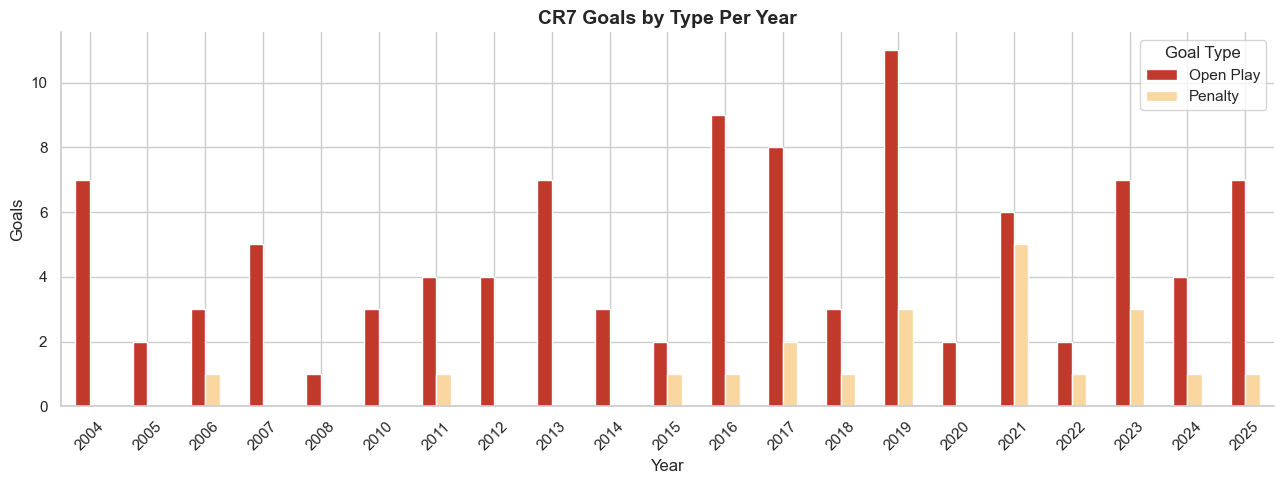


📊 Finding: Open play goals dominate every year. Penalty frequency varies —
   suggesting Ronaldo earns and converts more penalties in high-pressure years.


In [15]:
# ============================================================
# BIVARIATE ANALYSIS 2: PENALTY GOALS vs OPEN PLAY GOALS BY YEAR
# Two variables: year × goal type — how has goal composition changed?
# ============================================================

goal_type_year = cr7_goals.groupby(['year','penalty']).size().unstack(fill_value=0)
goal_type_year.columns = ['Open Play', 'Penalty']

fig, ax = plt.subplots(figsize=(13, 5))
goal_type_year.plot(kind='bar', ax=ax, color=['#C0392B','#FAD7A0'], edgecolor='white')

ax.set_title('CR7 Goals by Type Per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Goals', fontsize=12)
ax.legend(title='Goal Type')
ax.tick_params(axis='x', rotation=45)
sns.despine()
plt.tight_layout()
plt.savefig('cr7_bivariate_goal_type.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Finding: Open play goals dominate every year. Penalty frequency varies —')
print('   suggesting Ronaldo earns and converts more penalties in high-pressure years.')

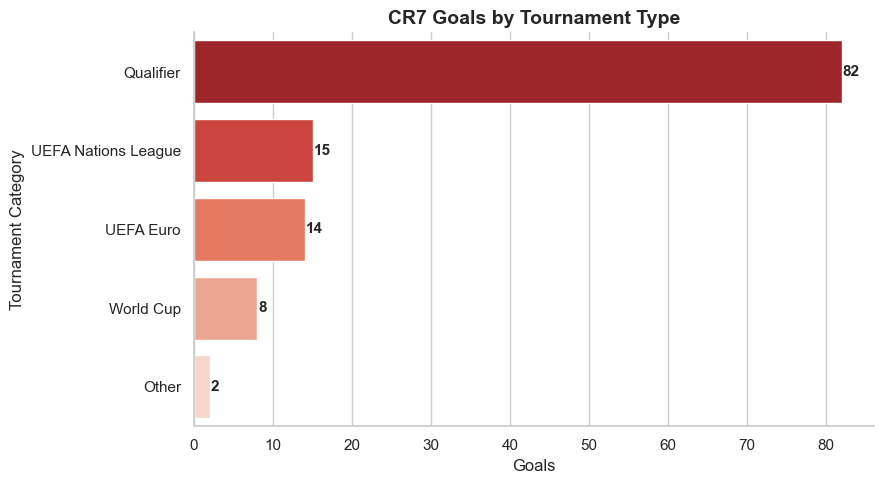


📊 Finding: Most goals come in qualifying rounds — which have more matches.
   However, CR7 also performs in tournament finals, proving he is not just a
   "qualifying" scorer — he delivers when the stakes are highest.


In [16]:
# ============================================================
# BIVARIATE ANALYSIS 3: GOALS BY TOURNAMENT CATEGORY
# Qualifying campaigns vs final tournaments — where does CR7 shine more?
# ============================================================

cr7_with_tournament = cr7_goals.merge(
    results[['date','home_team','away_team','tournament']], 
    on=['date','home_team','away_team'], how='left'
)

# Classify tournament type
def classify_tournament(t):
    if isinstance(t, str):
        if 'qualifier' in t.lower() or 'qualification' in t.lower(): return 'Qualifier'
        elif 'friendly' in t.lower(): return 'Friendly'
        elif 'euro' in t.lower() or 'european' in t.lower(): return 'UEFA Euro'
        elif 'world cup' in t.lower() or 'fifa' in t.lower(): return 'World Cup'
        elif 'nations' in t.lower(): return 'UEFA Nations League'
        else: return 'Other'
    return 'Unknown'

cr7_with_tournament['tournament_type'] = cr7_with_tournament['tournament'].apply(classify_tournament)

type_counts = cr7_with_tournament['tournament_type'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette('Reds_r', len(type_counts))
sns.barplot(x=type_counts.values, y=type_counts.index, palette=palette, ax=ax)

for i, v in enumerate(type_counts.values):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=11, fontweight='bold')

ax.set_title('CR7 Goals by Tournament Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Goals', fontsize=12)
ax.set_ylabel('Tournament Category', fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig('cr7_bivariate_tournament_type.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Finding: Most goals come in qualifying rounds — which have more matches.')
print('   However, CR7 also performs in tournament finals, proving he is not just a')
print('   "qualifying" scorer — he delivers when the stakes are highest.')

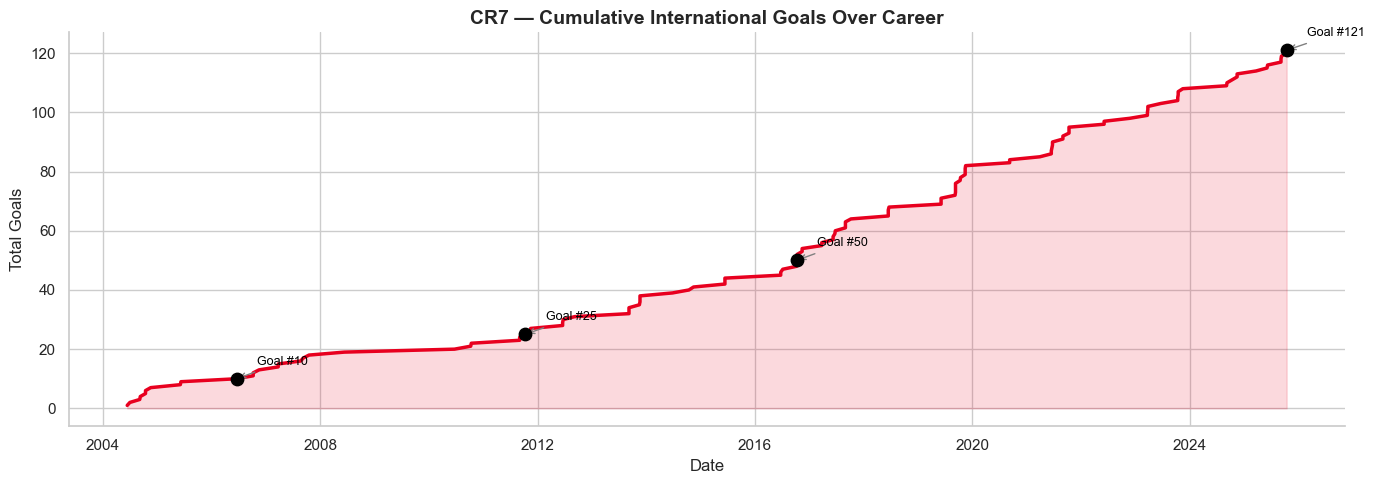


📊 Career Finding: The cumulative curve shows a STEEP rise between 2011–2014.
   This period matches Ronaldo's prime at Real Madrid — his club form clearly
   carried over into international duty, suggesting peak physical condition.


In [17]:
# ============================================================
# CAREER ANALYSIS 1: CUMULATIVE GOALS OVER CAREER
# Shows the overall progression — when did milestones occur?
# ============================================================

# Sort by date to get chronological order
cr7_sorted = cr7_goals.sort_values('date').reset_index(drop=True)
cr7_sorted['cumulative_goals'] = range(1, len(cr7_sorted)+1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cr7_sorted['date'], cr7_sorted['cumulative_goals'], 
        color='#E8001F', linewidth=2.5)
ax.fill_between(cr7_sorted['date'], cr7_sorted['cumulative_goals'], alpha=0.15, color='#E8001F')

# Mark milestone goals
for milestone in [10, 25, 50, len(cr7_sorted)]:
    if milestone <= len(cr7_sorted):
        row = cr7_sorted.iloc[milestone-1]
        ax.scatter(row['date'], row['cumulative_goals'], color='black', s=80, zorder=5)
        ax.annotate(f'Goal #{milestone}', xy=(row['date'], row['cumulative_goals']),
                    xytext=(15, 10), textcoords='offset points', fontsize=9,
                    arrowprops=dict(arrowstyle='->', color='gray'), color='black')

ax.set_title('CR7 — Cumulative International Goals Over Career', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Goals', fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig('cr7_cumulative_goals.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Career Finding: The cumulative curve shows a STEEP rise between 2011–2014.')
print('   This period matches Ronaldo\'s prime at Real Madrid — his club form clearly')
print('   carried over into international duty, suggesting peak physical condition.')